# Authorship analysis

Analyses authorship of the non-conceptual papers in `data-clean/all-data.csv`, in particular
the overlap of authors between the AGILE and GIScience conference series.

For every paper we resolve the DOI from the `link` column and query **OpenAlex** (via `pyalex`)
to obtain authors and their ORCIDs. Authors are then reconciled across papers, preferring ORCID
over author name (so that a person who changed their name is still matched to a single identity),
with a normalised-name fallback for authors without an ORCID.

OpenAlex misses a handful of registered DOIs (notably Dagstuhl LIPIcs entries). For those we fall
back to an OpenAlex title search (checking the work's `locations[]` list for parallel hostings)
and, as a last resort, to scraping schema.org `ScholarlyArticle` metadata from the publisher
landing page HTML head.

Conceptual papers (`consolidated_cp == True`) are excluded.

Raw JSON responses are cached under `data/authorship-cache/` to keep re-runs cheap; the
cache is git-ignored.

### Related work

Earlier work by Keßler, Janowicz, and Kauppinen explored the GIScience research field through
linked data built from conference metadata: *spatial@linkedscience -- Exploring the Research
Field of GIScience with Linked Data*, GIScience 2012 (LNCS 7478),
[doi:10.1007/978-3-642-33024-7_8](https://doi.org/10.1007/978-3-642-33024-7_8). That work
established a linked-data view of the community that complements the paper-level authorship
reconciliation pursued here.

## 1. Setup

All dependencies are declared in [`04_environment.yml`](04_environment.yml): the conda packages
`matplotlib-base`, `matplotlib-venn`, and `requests` (already present from the base env), plus
`pyalex` via pip.

Helper functions live in [`authorship_utils.py`](authorship_utils.py) next to this notebook --
DOI extraction, OpenAlex fetching with on-disk caching, schema.org JSON-LD landing-page
fallback, title similarity, author normalisation, and identity resolution.

In [2]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyalex
from matplotlib_venn import venn2

import authorship_utils as au

MAILTO = "daniel.nuest@tu-dresden.de"
pyalex.config.email = MAILTO

USER_AGENT = (
    f"reproducible-research-giscience-longitudinal-study/1.0 (mailto:{MAILTO})"
)

INPUT_CSV = "data-clean/all-data.csv"
CACHE_DIR = Path("data/authorship-cache")
OPENALEX_CACHE = CACHE_DIR / "openalex"
OPENALEX_CACHE.mkdir(parents=True, exist_ok=True)

FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 120)

## 2. Load and filter papers

Drop conceptual papers as requested; only `consolidated_cp == False` is considered.

In [3]:
df_all = pd.read_csv(INPUT_CSV)
df = df_all[df_all["consolidated_cp"] == False].copy().reset_index(drop=True)
print(f"total papers: {len(df_all)}")
print(f"non-conceptual papers analysed: {len(df)}")
print(df.groupby("conf").size())

total papers: 224
non-conceptual papers analysed: 203
conf
agile        130
giscience     73
dtype: int64


## 3. Resolve DOIs from the `link` column

The `link` column contains a mix of forms:

- `https://doi.org/...` -- use directly.
- Springer `.../chapter/10.XXXX/...` -- the DOI is the tail starting at `10.`.
- Copernicus `agile-giss.copernicus.org/articles/{vol}/{art}/{year}/` -- assemble
  `10.5194/agile-giss-{vol}-{art}-{year}`.
- Dagstuhl `drops.dagstuhl.de/.../LIPIcs.GIScience.{year}.{n}/...` -- assemble
  `10.4230/LIPIcs.GIScience.{year}.{n}`.
- Anything else is logged as unresolved.

In [4]:
df["doi"] = df["link"].map(au.extract_doi)
missing = df[df["doi"].isna()][["paper", "link"]]
print(f"DOIs resolved: {df['doi'].notna().sum()} / {len(df)}")
if not missing.empty:
    print("\nUnresolved links:")
    display(missing)

DOIs resolved: 203 / 203


## 4. Fetch metadata from OpenAlex

Each paper's JSON payload is cached on disk so re-runs are offline. Delete
`data/authorship-cache/` to force a refresh.

OpenAlex fetches try, in order:

1. **Direct DOI lookup** via `pyalex.Works()[doi_url]`.
2. **Title-search fallback** when (1) returns 404, accepting a candidate if its primary DOI
   matches, if the registered DOI appears in the candidate's `locations[]` list (parallel
   hostings: preprints, repositories, re-publications), or if title similarity and year match
   strongly.
3. **Landing-page JSON-LD scrape** when (2) also fails, parsing the publisher's schema.org
   `ScholarlyArticle` metadata from `<script type="application/ld+json">`. This covers the
   cases where a DOI is not indexed by OpenAlex at all (e.g. Dagstuhl LIPIcs pages serve rich
   schema.org metadata including ORCIDs as `sameAs`).

Transient API errors are retried a few times before giving up.

In [5]:
# Thin wrapper binds the fetch helper to this notebook's cache dir and user agent.
def fetch_openalex(doi, title, year):
    return au.fetch_openalex(
        doi, OPENALEX_CACHE,
        expected_title=title, expected_year=year,
        landing_page_url=f"https://doi.org/{doi}",
        landing_page_user_agent=USER_AGENT,
    )

In [6]:
openalex_data: dict[str, dict] = {}

for i, row in df.iterrows():
    doi = row["doi"]
    if not doi:
        continue
    if i % 25 == 0:
        print(f"[{i+1}/{len(df)}] {row['paper']} -> {doi}")
    openalex_data[doi] = fetch_openalex(doi, row["title"], int(row["year"])) or {}

oa_found = sum(1 for v in openalex_data.values() if v and not v.get("_not_found"))
recovered = sum(1 for v in openalex_data.values() if v and v.get("_recovered_via"))
print(f"\nOpenAlex hits: {oa_found} / {len(openalex_data)}  (of which {recovered} via fallback)")

recovered_rows = [
    {"doi": doi, "recovered_via": v.get("_recovered_via"), "openalex_doi": v.get("doi")}
    for doi, v in openalex_data.items()
    if v and v.get("_recovered_via")
]
if recovered_rows:
    display(pd.DataFrame(recovered_rows))

[1/203] agile_2017_006 -> 10.1007/978-3-319-56759-4_6
[26/203] giscience_2021_024 -> 10.4230/lipics.giscience.2021.ii.8
[51/203] giscience_2021_017 -> 10.4230/lipics.giscience.2021.ii.1
[76/203] giscience_2021_019 -> 10.4230/lipics.giscience.2021.ii.3
[101/203] giscience_2021_014 -> 10.4230/lipics.giscience.2021.i.14
[126/203] giscience_2018_015 -> 10.4230/LIPIcs.GIScience.2018.15
[151/203] giscience_2021_012 -> 10.4230/lipics.giscience.2021.i.12
[176/203] giscience_2021_029 -> 10.4230/lipics.giscience.2021.ii.13
[201/203] giscience_2021_018 -> 10.4230/lipics.giscience.2021.ii.2

OpenAlex hits: 203 / 203  (of which 11 via fallback)


,doi,recovered_via,openalex_doi
0,10.5194/agile-giss-4-3-2023,doi-exact,https://doi.org/10.5194/agile-giss-4-3-2023
1,10.4230/LIPIcs.GIScience.2018.8,doi-exact,https://doi.org/10.4230/lipics.giscience.2018.8
2,10.4230/lipics.giscience.2021.i.17,doi-exact,https://doi.org/10.4230/lipics.giscience.2021.i.17
3,10.4230/lipics.giscience.2021.i.2,landing-page-jsonld,https://doi.org/10.4230/lipics.giscience.2021.i.2
4,10.5194/agile-giss-1-2-2020,doi-exact,https://doi.org/10.5194/agile-giss-1-2-2020
5,10.4230/lipics.giscience.2021.i.6,doi-in-locations,https://doi.org/10.4230/lipics.cosit.2022.1
6,10.5194/agile-giss-3-3-2022,doi-exact,https://doi.org/10.5194/agile-giss-3-3-2022
7,10.5194/agile-giss-3-19-2022,doi-exact,https://doi.org/10.5194/agile-giss-3-19-2022
8,10.4230/lipics.giscience.2021.i.4,doi-in-locations,https://doi.org/10.20944/preprints202002.0326.v1
9,10.5194/agile-giss-1-12-2020,doi-exact,https://doi.org/10.5194/agile-giss-1-12-2020


## 5. Verify paper title against OpenAlex

Fuzzy match on lowercased, punctuation-stripped titles; below 0.80 similarity is flagged.
The recorded `title` in `all-data.csv` stays authoritative -- this is a sanity check that the
DOI we resolved points to the same paper.

In [7]:
verify_rows = []
for _, row in df.iterrows():
    doi = row["doi"]
    if not doi:
        continue
    oa = openalex_data.get(doi) or {}
    oa_title = au.openalex_title(oa)
    verify_rows.append(
        {
            "paper": row["paper"],
            "title": row["title"],
            "doi": doi,
            "openalex_title": oa_title,
            "sim_openalex": au.title_similarity(row["title"], oa_title),
        }
    )

verify_df = pd.DataFrame(verify_rows)
low_match = verify_df[verify_df["sim_openalex"] < 0.80]
print(f"Titles with similarity <0.80: {len(low_match)} / {len(verify_df)}")
display(low_match.sort_values("sim_openalex"))

Titles with similarity <0.80: 1 / 203


,paper,title,doi,openalex_title,sim_openalex
116,agile_2022_011,Machine Learning with Kay,10.5194/agile-giss-3-11-2022,Machine Learning with &amp;lt;i&amp;gt;Kay&amp;lt;/i&amp;gt;,0.609756


## 6. Extract authors and ORCIDs

Per paper we read the OpenAlex `authorships[]` list in its native order, capturing the display
name and ORCID (if any) for each author.

In [8]:
author_rows = []

for _, row in df.iterrows():
    doi = row["doi"]
    oa_list = au.openalex_authors(openalex_data.get(doi) or {})
    for position, a in enumerate(oa_list, start=1):
        author_rows.append(
            {
                "paper": row["paper"],
                "conf": row["conf"],
                "year": row["year"],
                "doi": doi,
                "position": position,
                "name": a["name"],
                "orcid": a["orcid"],
            }
        )

authors_df = pd.DataFrame(author_rows)
print(f"author-paper rows: {len(authors_df)}")
print(f"papers with at least one author: {authors_df['paper'].nunique()}")
print(
    f"ORCID coverage: {authors_df['orcid'].notna().sum()} / {len(authors_df)} "
    f"({authors_df['orcid'].notna().mean():.1%})"
)

author-paper rows: 715
papers with at least one author: 203
ORCID coverage: 571 / 715 (79.9%)


## 7. Build author identities

Identity rule: ORCID is preferred (covers name changes). For authors without an ORCID in
the OpenAlex record, we use a normalised-name key.

A second pass then upgrades name-only identities to ORCID identities whenever an ORCID row
for the same normalised name exists somewhere in the corpus -- that fixes the common case
of an author appearing as ORCID-tagged on one paper and untagged on another. When two
different ORCIDs share a normalised name (i.e. genuine namesakes), the merge is skipped to
avoid collapsing two different people.

The remaining pure name-only identities can still split a single person who appears under
different name spellings, and can conflate two people with identical names -- both are
reported in the counts below so readers can reason about the error bar.

In [9]:
# Two-pass identity resolution:
# 1. ORCID-first identity per row (from OpenAlex).
# 2. Post-hoc merge: upgrade name-only identities to ORCID identities when an ORCID row
#    for the same normalised name exists in the corpus, OR when a manual decision
#    has been recorded in data/orcid-resolutions.csv (see the optional cell below).
ORCID_DECISIONS = Path("data/orcid-resolutions.csv")
decisions_df = pd.read_csv(ORCID_DECISIONS) if ORCID_DECISIONS.exists() else None

authors_df["identity"] = au.merge_name_only_identities(
    authors_df["orcid"], authors_df["name"], manual_resolutions=decisions_df,
)

id_to_name = (
    authors_df.groupby("identity")["name"]
    .agg(lambda s: Counter(s).most_common(1)[0][0])
    .to_dict()
)

n_total = authors_df["identity"].nunique()
n_orcid = sum(1 for i in authors_df["identity"].unique() if i.startswith("orcid:"))
n_name = n_total - n_orcid
n_manual = (decisions_df["chosen_orcid"].astype(str).str.upper() != "NONE").sum() if decisions_df is not None else 0
print(f"distinct author identities: {n_total}")
print(f"  - with ORCID (incl. merged name-only rows): {n_orcid}")
print(f"  - name-fallback only:                        {n_name}")
print(f"  - manual resolutions in effect:              {n_manual}")

distinct author identities: 519
  - with ORCID (incl. merged name-only rows): 402
  - name-fallback only:                        117
  - manual resolutions in effect:              0


### Optional: resolve remaining name-only identities against ORCID

Many remaining name-only identities are people who simply did not list an ORCID on a
particular paper. The workflow below queries the **ORCID public API** for matching profiles
and lets you attach each name to a specific ORCID (or mark it explicitly as "no match").
Decisions are stored in [`data/orcid-resolutions.csv`](data/orcid-resolutions.csv); the file
is committed to git so resolutions are persistent and consulted by the identity-merge cell
above on every subsequent run.

The review is split into two non-blocking steps so it works in every Jupyter frontend
(JupyterLab, VS Code, Cursor, nbclassic) -- no `input()` prompt, no blocked kernel:

1. **Prepare & display.** The first cell queries ORCID for every undecided name-only
   identity, writes a CSV template at [`data/orcid-candidates.csv`](data/orcid-candidates.csv),
   and renders each queue item as Markdown with **clickable DOI links** (so you can open
   the landing page of every paper the author appears on in our corpus, alongside the
   paper title) and **clickable ORCID links** (so you can open each candidate profile
   directly).
2. **Record decisions.** Edit `data/orcid-candidates.csv` in-place: set the
   `chosen_orcid` column to either an ORCID (accept that candidate), `NONE` (no match --
   prevents re-querying), or leave it blank to skip for now. Optional free-text in `notes`.
3. **Apply.** The second cell validates the template, appends the decisions to
   `data/orcid-resolutions.csv`, then re-run the identity cell above to apply them.

The whole block does nothing unless `RUN_ORCID_RESOLUTION` is `True`, because the manual
edit step should not run during automated notebook execution.

In [ ]:
RUN_ORCID_RESOLUTION = True  # set to False to skip the ORCID review entirely
ORCID_CANDIDATES = Path("data/orcid-candidates.csv")

# Step 1 of 3: build the queue and render it with clickable DOI and ORCID links.
# This cell is safe to re-run -- partially filled-in values in orcid-candidates.csv
# are preserved when the template is regenerated.
if RUN_ORCID_RESOLUTION:
    orcid_queue = au.prepare_orcid_resolution(
        authors_df,
        df,                       # papers_df: provides the paper titles for display
        decisions_path=ORCID_DECISIONS,
        candidates_path=ORCID_CANDIDATES,
        user_agent=USER_AGENT,
        only_cross_year=False,     # set False to walk every name-only identity
    )
    au.display_orcid_resolution(orcid_queue, candidates_path=ORCID_CANDIDATES)

*Nothing to resolve — all eligible name-only identities already have a recorded decision.*

In [11]:
# Step 3 of 3: apply the decisions you entered into data/orcid-candidates.csv.
# Reads the template, validates each `chosen_orcid` (ORCID or 'NONE'), and appends
# to data/orcid-resolutions.csv. Idempotent -- rows already in the decisions file
# are skipped. Re-run the identity cell above afterwards to merge the new resolutions.
if RUN_ORCID_RESOLUTION and ORCID_CANDIDATES.exists():
    au.apply_orcid_resolutions(ORCID_CANDIDATES, ORCID_DECISIONS)

applied 1 new decision(s); 0 template row(s) skipped; decisions file now has 4 total row(s).


## 8. Part A -- Overlap over the whole corpus

This part treats each conference as a single set of author identities pooled across **all** years
in the corpus. Results here answer *"how much does the AGILE author community overlap with the
GIScience author community at all, irrespective of timing?"*. Temporal dynamics are deferred to
Part B.

### A.1 Distinct authors per conference and the intersection

In [10]:
agile_ids = set(authors_df[authors_df["conf"] == "agile"]["identity"])
gis_ids = set(authors_df[authors_df["conf"] == "giscience"]["identity"])
both_ids = agile_ids & gis_ids

print(f"AGILE-only authors:     {len(agile_ids - gis_ids)}")
print(f"GIScience-only authors: {len(gis_ids - agile_ids)}")
print(f"In both conferences:    {len(both_ids)}")

both_orcid = {i for i in both_ids if i.startswith("orcid:")}
both_name = both_ids - both_orcid
print(
    f"  of which matched by ORCID:        {len(both_orcid)}"
)
print(
    f"  of which matched by name-fallback: {len(both_name)}  (interpret with care)"
)

AGILE-only authors:     314
GIScience-only authors: 167
In both conferences:    38
  of which matched by ORCID:        37
  of which matched by name-fallback: 1  (interpret with care)


### A.2 Figure 1: Venn diagram

Distinct author identities per conference, pooled across all years.

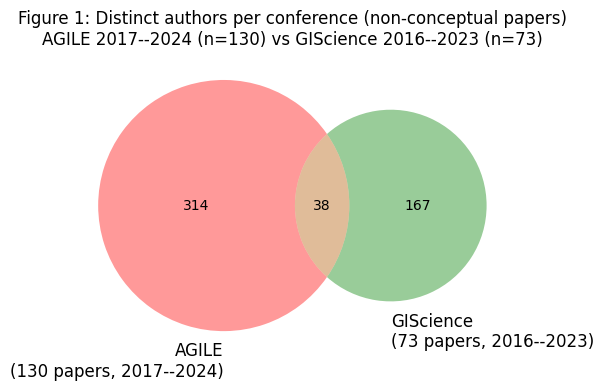

In [11]:
ag_papers = df[df["conf"] == "agile"]
gi_papers = df[df["conf"] == "giscience"]
ag_range = f"{int(ag_papers['year'].min())}--{int(ag_papers['year'].max())}"
gi_range = f"{int(gi_papers['year'].min())}--{int(gi_papers['year'].max())}"

fig, ax = plt.subplots(figsize=(6, 5.4))
venn2(
    [agile_ids, gis_ids],
    set_labels=(
        f"AGILE\n({len(ag_papers)} papers, {ag_range})",
        f"GIScience\n({len(gi_papers)} papers, {gi_range})",
    ),
    ax=ax,
)
ax.set_title(
    f"Figure 1: Distinct authors per conference (non-conceptual papers)\n"
    f"AGILE {ag_range} (n={len(ag_papers)}) vs GIScience {gi_range} (n={len(gi_papers)})"
)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure1_authorship_venn.png", dpi=150)
fig.savefig(FIG_DIR / "figure1_authorship_venn.pdf")
plt.show()

### A.3 Papers with at least one cross-conference author

For each paper, check whether any of its authors (by identity) also appears on **any** paper at
the other conference series (any year). This is the corpus-wide, time-agnostic count. Reported for
the whole corpus, per-conference, and with identities resolved either via ORCID only (stricter,
more reliable) or via the full identity set including the normalised-name fallback for authors
without an ORCID.

In [12]:
# Map each identity to the set of conferences it appears in.
identity_confs = (
    authors_df.groupby("identity")["conf"].agg(lambda s: set(s)).to_dict()
)

# ORCID-only identities (drop name-fallback authors entirely).
orcid_identity_confs = (
    authors_df[authors_df["orcid"].notna()]
    .groupby("identity")["conf"].agg(lambda s: set(s)).to_dict()
)


def paper_cross_conf(paper_df: pd.DataFrame, identity_map: dict) -> pd.Series:
    per_paper = {}
    for paper, grp in paper_df.groupby("paper"):
        this_conf = grp["conf"].iloc[0]
        cross = any(
            (identity_map.get(ident, set()) - {this_conf})
            for ident in grp["identity"]
        )
        per_paper[paper] = cross
    return pd.Series(per_paper, name="cross_conf")


cross_any = paper_cross_conf(authors_df, identity_confs)
cross_orcid = paper_cross_conf(
    authors_df[authors_df["orcid"].notna()], orcid_identity_confs
)

paper_conf = authors_df.groupby("paper")["conf"].first()


def summarise(series: pd.Series, label: str) -> None:
    df_ = series.to_frame().join(paper_conf)
    total = len(df_)
    n_cross = int(df_["cross_conf"].sum())
    print(f"[{label}] overall: {n_cross} / {total} papers have >=1 cross-conference author")
    for conf, sub in df_.groupby("conf"):
        print(
            f"  {conf:>9}: {int(sub['cross_conf'].sum())} / {len(sub)} "
            f"({sub['cross_conf'].mean():.1%})"
        )


summarise(cross_any, "any identity (ORCID + name-fallback)")
print()
summarise(cross_orcid, "ORCID-only")

[any identity (ORCID + name-fallback)] overall: 79 / 203 papers have >=1 cross-conference author
      agile: 46 / 130 (35.4%)
  giscience: 33 / 73 (45.2%)

[ORCID-only] overall: 73 / 199 papers have >=1 cross-conference author
      agile: 43 / 129 (33.3%)
  giscience: 30 / 70 (42.9%)


### A.4 Cross-conference authors -- paper counts per conference

Basic listing: every author identity in both conferences (over the whole corpus) with the number
of papers at each and the list of years they appear in.

In [13]:
overlap_rows = []
for ident in both_ids:
    sub = authors_df[authors_df["identity"] == ident]
    overlap_rows.append(
        {
            "name": id_to_name[ident],
            "identity": ident,
            "orcid": ident.split(":", 1)[1] if ident.startswith("orcid:") else None,
            "agile_papers": sub[sub["conf"] == "agile"]["paper"].nunique(),
            "giscience_papers": sub[sub["conf"] == "giscience"]["paper"].nunique(),
            "total_papers": sub["paper"].nunique(),
            "years": ",".join(str(y) for y in sorted(sub["year"].unique())),
        }
    )

overlap_df = (
    pd.DataFrame(overlap_rows)
    .sort_values(["total_papers", "name"], ascending=[False, True])
    .reset_index(drop=True)
)
display(overlap_df)

,name,identity,orcid,agile_papers,giscience_papers,total_papers,years
0,Ioannis Giannopoulos,orcid:0000-0002-2556-5230,0000-0002-2556-5230,5,6,11,"2016,2018,2019,2020,2021,2023,2024"
1,Martin Raubal,orcid:0000-0001-5951-6835,0000-0001-5951-6835,7,4,11,"2016,2017,2018,2019,2020,2021,2022,2023"
2,Krzysztof Janowicz,orcid:0009-0003-1968-887X,0009-0003-1968-887X,8,2,10,"2017,2018,2019,2020,2021,2022"
3,Henry Martin,orcid:0000-0002-0456-8539,0000-0002-0456-8539,5,3,8,"2018,2019,2020,2021,2022,2023"
4,Dominik Bucher,orcid:0000-0001-9824-5388,0000-0001-9824-5388,3,3,6,"2018,2019,2020,2021"
5,Gengchen Mai,orcid:0000-0002-7818-7309,0000-0002-7818-7309,5,1,6,"2018,2019,2020,2021,2022"
6,Carsten Keßler,orcid:0000-0002-9724-820X,0000-0002-9724-820X,4,1,5,"2016,2018,2019,2020,2022"
7,Jan‐Henrik Haunert,orcid:0000-0001-8005-943X,0000-0001-8005-943X,1,4,5,"2016,2018,2020,2021"
8,Markus Kattenbeck,orcid:0000-0001-6028-0428,0000-0001-6028-0428,1,4,5,"2018,2020,2021"
9,Stephan Winter,orcid:0000-0002-3403-6939,0000-0002-3403-6939,4,1,5,"2017,2019,2020,2023"


### A.5 Cross-conference author statistics -- detailed

For every author identity that appears in **both** conferences (over the whole corpus), show how
many papers they co-authored at each, their first and last year in the corpus, and the span of
years covered. Names in parentheses indicate identities matched via the normalised-name fallback
(no ORCID); treat those rows with extra care because name collisions and name-variant splits are
possible.

In [14]:
cross_stats_rows = []
for ident in both_ids:
    sub = authors_df[authors_df["identity"] == ident]
    years = sorted(sub["year"].unique())
    is_orcid = ident.startswith("orcid:")
    display_name = id_to_name[ident] if is_orcid else f"({id_to_name[ident]})"
    cross_stats_rows.append(
        {
            "name": display_name,
            "orcid": ident.split(":", 1)[1] if is_orcid else None,
            "agile_papers": sub[sub["conf"] == "agile"]["paper"].nunique(),
            "giscience_papers": sub[sub["conf"] == "giscience"]["paper"].nunique(),
            "total_papers": sub["paper"].nunique(),
            "first_year": int(years[0]),
            "last_year": int(years[-1]),
            "year_span": int(years[-1] - years[0]),
            "match": "orcid" if is_orcid else "name",
        }
    )

cross_stats_df = (
    pd.DataFrame(cross_stats_rows)
    .sort_values(
        ["total_papers", "agile_papers", "giscience_papers", "name"],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

print(
    f"cross-conference authors: {len(cross_stats_df)} "
    f"(orcid-matched: {(cross_stats_df['match']=='orcid').sum()}, "
    f"name-matched: {(cross_stats_df['match']=='name').sum()})"
)
display(cross_stats_df)

cross_stats_df.to_csv("data/authors-cross-conference.csv", index=False)
print("wrote data/authors-cross-conference.csv")

cross-conference authors: 38 (orcid-matched: 37, name-matched: 1)


,name,orcid,agile_papers,giscience_papers,total_papers,first_year,last_year,year_span,match
0,Martin Raubal,0000-0001-5951-6835,7,4,11,2016,2023,7,orcid
1,Ioannis Giannopoulos,0000-0002-2556-5230,5,6,11,2016,2024,8,orcid
2,Krzysztof Janowicz,0009-0003-1968-887X,8,2,10,2017,2022,5,orcid
3,Henry Martin,0000-0002-0456-8539,5,3,8,2018,2023,5,orcid
4,Gengchen Mai,0000-0002-7818-7309,5,1,6,2018,2022,4,orcid
5,Dominik Bucher,0000-0001-9824-5388,3,3,6,2018,2021,3,orcid
6,Carsten Keßler,0000-0002-9724-820X,4,1,5,2016,2022,6,orcid
7,Stephan Winter,0000-0002-3403-6939,4,1,5,2017,2023,6,orcid
8,Jan‐Henrik Haunert,0000-0001-8005-943X,1,4,5,2016,2021,5,orcid
9,Markus Kattenbeck,0000-0001-6028-0428,1,4,5,2018,2021,3,orcid


wrote data/authors-cross-conference.csv


### A.6 Most-published author identities (any conference)

Top 20 distinct author identities by total number of papers in the corpus, regardless of
conference. Included here for context; cross-conference overlap is in A.1–A.5.

In [15]:
top_overall = (
    authors_df.groupby("identity")
    .agg(
        name=("name", lambda s: Counter(s).most_common(1)[0][0]),
        papers=("paper", "nunique"),
        agile=("conf", lambda s: (s == "agile").sum()),
        giscience=("conf", lambda s: (s == "giscience").sum()),
    )
    .sort_values("papers", ascending=False)
    .head(20)
)
display(top_overall)

,name,papers,agile,giscience
identity,,,,
orcid:0000-0001-5951-6835,Martin Raubal,11,7,4
orcid:0000-0002-2556-5230,Ioannis Giannopoulos,11,5,6
orcid:0009-0003-1968-887X,Krzysztof Janowicz,10,8,2
orcid:0000-0002-0456-8539,Henry Martin,8,5,3
orcid:0000-0002-8514-7858,Bettina Speckmann,6,0,6
orcid:0000-0002-7818-7309,Gengchen Mai,6,5,1
orcid:0000-0002-6327-3976,Toshihiro Osaragi,6,6,0
orcid:0000-0001-9824-5388,Dominik Bucher,6,3,3
orcid:0000-0001-6028-0428,Markus Kattenbeck,5,1,4


## 9. Part B -- Year-by-year overlap

Part A pooled all years together, so an AGILE author from 2019 and a GIScience author from 2023
could be counted as overlapping. That's the right framing for *community overlap*, but misleading
for *temporal dynamics*: it "inherits" overlap from every other year, and it silently invents
overlap in GIScience off-years (2017, 2019, 2022, 2024), which had no GIScience conference at
all.

Part B constrains the question to a single year at a time: **in year *y*, how many authors
published at both AGILE and GIScience *that year*?** GIScience off-years must be zero by
construction.

### B.1 Shared-year authors and affected papers

In [16]:
# Universe of years present in the corpus.
corpus_years = sorted(authors_df["year"].unique())

# Years each conference actually met.
agile_years = set(authors_df[authors_df["conf"] == "agile"]["year"].unique())
gis_years = set(authors_df[authors_df["conf"] == "giscience"]["year"].unique())
print("AGILE years:    ", sorted(agile_years))
print("GIScience years:", sorted(gis_years))
shared_years = sorted(agile_years & gis_years)
print("Shared years (both conferences met):", shared_years)

# Per-year identity sets, per conference.
yearly_rows = []
for year in corpus_years:
    ag_set = set(
        authors_df[(authors_df["conf"] == "agile") & (authors_df["year"] == year)]["identity"]
    )
    gi_set = set(
        authors_df[(authors_df["conf"] == "giscience") & (authors_df["year"] == year)]["identity"]
    )
    shared = ag_set & gi_set

    ag_papers = authors_df[(authors_df["conf"] == "agile") & (authors_df["year"] == year)]
    gi_papers = authors_df[(authors_df["conf"] == "giscience") & (authors_df["year"] == year)]

    ag_cross_papers = ag_papers[ag_papers["identity"].isin(shared)]["paper"].nunique()
    gi_cross_papers = gi_papers[gi_papers["identity"].isin(shared)]["paper"].nunique()
    ag_total = ag_papers["paper"].nunique()
    gi_total = gi_papers["paper"].nunique()

    yearly_rows.append(
        {
            "year": year,
            "shared_authors": len(shared),
            "agile_papers": ag_total,
            "giscience_papers": gi_total,
            "agile_cross_papers": ag_cross_papers,
            "giscience_cross_papers": gi_cross_papers,
            "agile_cross_share": (ag_cross_papers / ag_total) if ag_total else 0.0,
            "giscience_cross_share": (gi_cross_papers / gi_total) if gi_total else 0.0,
            "both_met": (year in agile_years) and (year in gis_years),
        }
    )

yearly_overlap = pd.DataFrame(yearly_rows)
display(yearly_overlap)

AGILE years:     [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
GIScience years: [np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2023)]
Shared years (both conferences met): [np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2023)]


,year,shared_authors,agile_papers,giscience_papers,agile_cross_papers,giscience_cross_papers,agile_cross_share,giscience_cross_share,both_met
0,2016,0,0,17,0,0,0.000000,0.000000,False
1,2017,0,16,0,0,0,0.000000,0.000000,False
2,2018,2,17,17,1,2,0.058824,0.117647,True
3,2019,0,18,0,0,0,0.000000,0.000000,False
4,2020,6,21,15,3,3,0.142857,0.200000,True
5,2021,3,13,13,2,3,0.153846,0.230769,True
6,2022,0,20,0,0,0,0.000000,0.000000,False
7,2023,1,13,11,1,1,0.076923,0.090909,True
8,2024,0,12,0,0,0,0.000000,0.000000,False


### B.2 Figure 2: Papers with a same-year cross-conference author

Two directions, plotted separately:

- **AGILE to GIScience:** AGILE papers in year *y* for which at least one author *also*
  co-authored a GIScience paper in year *y*.
- **GIScience to AGILE:** GIScience papers in year *y* for which at least one author *also*
  co-authored an AGILE paper in year *y*.

In years without a GIScience conference (2017, 2019, 2022, 2024) both series are zero by
construction.

Styling follows the convention used in the R/Quarto notebooks (Brewer `Set1`, Tufte-style
minimal theme).

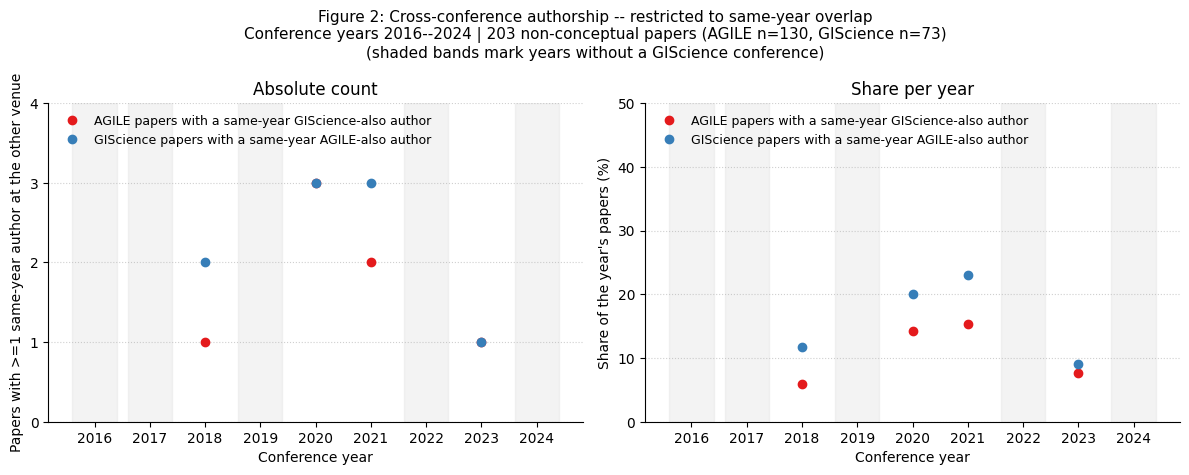

wrote data/authors-cross-conference-yearly.csv


In [17]:
from matplotlib.ticker import MaxNLocator

SET1 = plt.get_cmap("Set1").colors
AG_LABEL = "AGILE papers with a same-year GIScience-also author"
GI_LABEL = "GIScience papers with a same-year AGILE-also author"
dir_colors = {AG_LABEL: SET1[0], GI_LABEL: SET1[1]}

fig, (ax_n, ax_p) = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

# Drop years where the structural overlap is undefined (one of the conferences
# did not run that year). The grey bands still mark those years explicitly.
yo = yearly_overlap[yearly_overlap["both_met"]].sort_values("year")
off_years = [
    int(y) for y in sorted(yearly_overlap["year"])
    if not yearly_overlap.loc[yearly_overlap["year"] == y, "both_met"].iloc[0]
]

# Markers only -- no connecting lines, since adjacent valid years can be far apart.
ax_n.plot(yo["year"], yo["agile_cross_papers"],
          marker="o", linestyle="", color=dir_colors[AG_LABEL], label=AG_LABEL)
ax_n.plot(yo["year"], yo["giscience_cross_papers"],
          marker="o", linestyle="", color=dir_colors[GI_LABEL], label=GI_LABEL)

ax_p.plot(yo["year"], yo["agile_cross_share"] * 100,
          marker="o", linestyle="", color=dir_colors[AG_LABEL], label=AG_LABEL)
ax_p.plot(yo["year"], yo["giscience_cross_share"] * 100,
          marker="o", linestyle="", color=dir_colors[GI_LABEL], label=GI_LABEL)

all_years = sorted(yearly_overlap["year"].unique())
for ax in (ax_n, ax_p):
    for y in off_years:
        ax.axvspan(y - 0.4, y + 0.4, color="lightgrey", alpha=0.25, zorder=0)
    ax.set_xlabel("Conference year")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", linestyle=":", alpha=0.6)
    ax.set_xticks(all_years)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

ax_n.set_ylim(0, 4)
ax_n.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_n.set_ylabel("Papers with >=1 same-year author at the other venue")
ax_n.set_title("Absolute count")

ax_p.set_ylim(0, 50)
ax_p.set_ylabel("Share of the year's papers (%)")
ax_p.set_title("Share per year")

# Subtitle with corpus extent (computational == non-conceptual papers).
year_min = int(df["year"].min())
year_max = int(df["year"].max())
subtitle = (
    f"Conference years {year_min}--{year_max} | "
    f"{len(df)} non-conceptual papers "
    f"(AGILE n={(df['conf']=='agile').sum()}, GIScience n={(df['conf']=='giscience').sum()})"
)
fig.suptitle(
    "Figure 2: Cross-conference authorship -- restricted to same-year overlap\n"
    + subtitle
    + "\n(shaded bands mark years without a GIScience conference)",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure2_authorship_cross_conf_timeline.png", dpi=150)
fig.savefig(FIG_DIR / "figure2_authorship_cross_conf_timeline.pdf")
plt.show()

yearly_overlap.to_csv("data/authors-cross-conference-yearly.csv", index=False)
print("wrote data/authors-cross-conference-yearly.csv")

## 10. Persist enriched outputs

The authoritative per-author-per-paper table is written to
[`data-clean/authors.csv`](data-clean/authors.csv) -- this is the only "final" curated
table for downstream use, and its schema is documented in
[`data-clean/README.md`](data-clean/README.md).

Derived / aggregate views, useful for the manuscript and quick re-use but trivially
regenerable from `authors.csv`, land in [`data/`](data/):

- `authors-overlap.csv`            -- cross-conference authors with paper counts and years
- `authors-cross-conference.csv`   -- detailed cross-conference statistics (year span etc.)
- `authors-cross-conference-yearly.csv` -- per-year same-year overlap counts
- `authors-title-verification.csv` -- DOI-vs-OpenAlex title sanity check (debug artifact)

In [18]:
# Authoritative table: one row per author-paper.
authors_df.to_csv("data-clean/authors.csv", index=False)
print("wrote data-clean/authors.csv (authoritative)")

# Derived / aggregate views (regenerable from authors.csv).
overlap_df.to_csv("data/authors-overlap.csv", index=False)
verify_df.to_csv("data/authors-title-verification.csv", index=False)
print("wrote data/authors-overlap.csv")
print("wrote data/authors-title-verification.csv")

wrote data-clean/authors.csv (authoritative)
wrote data/authors-overlap.csv
wrote data/authors-title-verification.csv
